# 12. LightGBM от начала до конца: отклик клиентов, 50 000 объектов, редкий класс

| | |
|---|---|
| **Уровень** | 3 из 4 — средние данные: полный цикл и типовые случаи (`3_medium`) |
| **Скрипт-источник** | [`12_lightgbm_complete.py`](../12_lightgbm_complete.py) — тот же код, запуск из терминала |
| **Время выполнения** | ≈ 3 с |

**Цель.** Полный рабочий цикл LightGBM для бинарной классификации.

### Чему вы научитесь

- Нативный `lgb.Dataset` и `lgb.train`
- Категориальные признаки
- Колбэки: журнал и ранняя остановка
- Метрики AUC и log-loss
- Важности split и gain
- Вклады признаков (`pred_contrib=True`)
- Сохранение в текстовый формат

### Данные

`_data.make_customers` — 50 000 клиентов, 8 признаков (возраст, доход с пропусками, стаж, покупки, дни с последней покупки, канал, регион из 50 значений, подписка), откликнулись 5%.

### План

1. **Этап 1.** Данные
2. **Этап 2.** Разбиение 60 / 20 / 20 со стратификацией по классу
3. **Этап 3.** lgb.train: Dataset, категории, журнал каждые 100 деревьев, ранняя остановка по log-loss
4. **Этап 4.** Качество на тесте
5. **Этап 5.** Важности: split (число разбиений) против gain (выигрыш)
6. **Этап 6.** Вклады признаков (TreeSHAP встроен: pred_contrib=True)
7. **Этап 7.** Сохранение в текстовый формат и загрузка

> Ноутбук собран из `examples/3_medium/12_lightgbm_complete.py` командой `python examples/build_notebooks.py`. Чтобы изменить пример, правьте скрипт и пересоберите ноутбук.

## Подготовка

Ячейка ниже находит папку `examples/` (ноутбук можно открыть из любой рабочей папки внутри
репозитория), подключает общий каркас примеров `_common.Example` и учебную библиотеку курса
`gbcourse`. Каркас печатает этапы и выводы, «раскрывает» датасет и показывает графики прямо в
ноутбуке. Выполняйте ячейки сверху вниз: **Run → Run All Cells**.

In [1]:
import sys
import tempfile
from pathlib import Path

EXAMPLES = next(p / "examples" for p in [Path.cwd(), *Path.cwd().parents]
                if (p / "examples" / "_common.py").is_file())
sys.path.insert(0, str(EXAMPLES))
from _common import Example
from _data import make_customers

ex = Example(EXAMPLES / "3_medium/12_lightgbm_complete.py", title="12. LightGBM от начала до конца: отклик клиентов",
             goal="пройти полный цикл LightGBM для бинарной классификации")

import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
from gbcourse.style import ROLE
from sklearn.metrics import average_precision_score, log_loss, roc_auc_score

## Этап 1. Данные

In [2]:
X, y = make_customers(ex.size(50_000, 10_000), positive_rate=0.05)
ex.describe(X, y, target="отклик", task="classification", source="examples/_data.py → make_customers")

   Источник: examples/_data.py → make_customers
   Объектов: 50 000   признаков: 8   память: 2.39 МБ
   Типы признаков: float64 × 3, int64 × 3, category × 2
   Пропуски: доход 8.8%
   Цель «отклик»: класс 0 — 47545 (95.1%), класс 1 — 2455 (4.9%)
   Первые строки:


,возраст,доход,стаж_мес,покупок,дней_с_покупки,канал,регион,подписка,[отклик]
0,42.0,42487.0,48,5,11.0,приложение,28,0,0
1,38.0,69589.0,88,13,33.0,партнёр,23,0,0
2,48.0,41080.0,103,5,30.0,сайт,12,0,0


## Этап 2. Разбиение 60 / 20 / 20 со стратификацией по классу

In [3]:
from sklearn.model_selection import train_test_split

X_tmp, X_te, y_tmp, y_te = train_test_split(X, y, test_size=0.2, stratify=y, random_state=0)
X_tr, X_va, y_tr, y_va = train_test_split(X_tmp, y_tmp, test_size=0.25, stratify=y_tmp, random_state=0)
print(f"   {len(y_tr)} / {len(y_va)} / {len(y_te)}; доля класса 1: {y_tr.mean():.3f} / {y_va.mean():.3f} / {y_te.mean():.3f}")

   30000 / 10000 / 10000; доля класса 1: 0.049 / 0.049 / 0.049


## Этап 3. lgb.train: Dataset, категории, журнал каждые 100 деревьев, ранняя остановка по log-loss

[100]	валидация's binary_logloss: 0.179166	валидация's auc: 0.723014


   ⏱ обучение: 0.66 с
   лучшая итерация 70


> ▸ **Вывод.** first\_metric\_only=True: останавливаемся по первой метрике (log-loss), AUC только записывается.

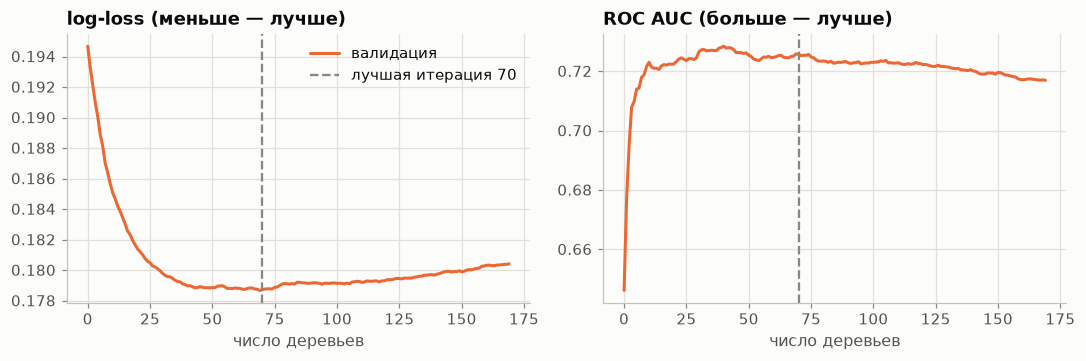

In [4]:
dtr = lgb.Dataset(X_tr, y_tr, categorical_feature=["канал", "регион"])
dva = lgb.Dataset(X_va, y_va, reference=dtr)
params = {"objective": "binary", "metric": ["binary_logloss", "auc"], "learning_rate": 0.05, "num_leaves": 31,
          "min_child_samples": 50, "feature_fraction": 0.8, "bagging_fraction": 0.8, "bagging_freq": 1,
          "cat_smooth": 20, "verbose": -1, "seed": 0}
history = {}
with ex.timer("обучение"):
    bst = lgb.train(params, dtr, num_boost_round=5000, valid_sets=[dva], valid_names=["валидация"],
                    callbacks=[lgb.log_evaluation(100), lgb.early_stopping(100, first_metric_only=True, verbose=False),
                               lgb.record_evaluation(history)])
print(f"   лучшая итерация {bst.best_iteration}")
ex.note("first_metric_only=True: останавливаемся по первой метрике (log-loss), AUC только записывается.")
fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))
for ax, key, label in ((axes[0], "binary_logloss", "log-loss (меньше — лучше)"), (axes[1], "auc", "ROC AUC (больше — лучше)")):
    ax.plot(history["валидация"][key], color=ROLE["valid"], lw=2, label="валидация")
    ax.axvline(bst.best_iteration, color=ROLE["truth"], ls="--", lw=1.5, label=f"лучшая итерация {bst.best_iteration}")
    ax.set(xlabel="число деревьев", title=label)
axes[0].legend()
fig.tight_layout()
ex.finish(fig, "12_validation_curves")

## Этап 4. Качество на тесте

In [5]:
p = bst.predict(X_te, num_iteration=bst.best_iteration)
print(f"   ROC AUC {roc_auc_score(y_te, p):.4f}, средняя точность (AP) {average_precision_score(y_te, p):.4f}, "
      f"log-loss {log_loss(y_te, p):.4f} (константа: {log_loss(y_te, np.full(len(y_te), y_tr.mean())):.4f})")
top = np.argsort(-p)[: len(p) // 10]
print(f"   в 10% клиентов с наибольшей вероятностью — {y_te[top].sum()} из {y_te.sum()} откликов ({y_te[top].sum() / y_te.sum():.0%})")
ex.note("При редком классе точность (accuracy) бесполезна: «никто не откликнется» даёт 95%. Смотрим AUC, AP и охват верха списка.")

   ROC AUC 0.7427, средняя точность (AP) 0.1583, log-loss 0.1766 (константа: 0.1959)
   в 10% клиентов с наибольшей вероятностью — 164 из 491 откликов (33%)


> ▸ **Вывод.** При редком классе точность (accuracy) бесполезна: «никто не откликнется» даёт 95%. Смотрим AUC, AP и охват верха списка.

## Этап 5. Важности: split (число разбиений) против gain (выигрыш)

In [6]:
split = bst.feature_importance("split")
gain = bst.feature_importance("gain")
for f, s_, g_ in sorted(zip(bst.feature_name(), split, gain), key=lambda t: -t[2]):
    print(f"   {f:14s} разбиений {s_:5d}   выигрыш {g_:10.1f}")

   доход          разбиений   465   выигрыш     5587.5
   регион         разбиений   335   выигрыш     4804.4
   дней_с_покупки разбиений   335   выигрыш     4765.5
   стаж_мес       разбиений   337   выигрыш     2562.2
   покупок        разбиений   234   выигрыш     1963.3
   возраст        разбиений   273   выигрыш     1918.3
   подписка       разбиений    70   выигрыш     1698.2
   канал          разбиений    51   выигрыш      366.3


## Этап 6. Вклады признаков (TreeSHAP встроен: pred_contrib=True)

In [7]:
contrib = bst.predict(X_te.iloc[:1000], num_iteration=bst.best_iteration, pred_contrib=True)
mean_abs = np.abs(contrib[:, :-1]).mean(0)
print("   средний |вклад| в логит: " + ", ".join(f"{f} {v:.3f}" for f, v in sorted(zip(bst.feature_name(), mean_abs), key=lambda t: -t[1])))
raw = bst.predict(X_te.iloc[:1000], num_iteration=bst.best_iteration, raw_score=True)
assert np.allclose(contrib.sum(1), raw)
ex.note("Сумма вкладов и базы равна сырому прогнозу (логиту) — свойство значений Шепли.")

   средний |вклад| в логит: дней_с_покупки 0.386, регион 0.321, доход 0.273, подписка 0.192, покупок 0.138, канал 0.083, возраст 0.057, стаж_мес 0.046


> ▸ **Вывод.** Сумма вкладов и базы равна сырому прогнозу (логиту) — свойство значений Шепли.

## Этап 7. Сохранение в текстовый формат и загрузка

In [8]:
with tempfile.TemporaryDirectory() as d:
    path = Path(d) / "customers.txt"
    bst.save_model(str(path), num_iteration=bst.best_iteration)
    loaded = lgb.Booster(model_file=str(path))
    same = np.allclose(loaded.predict(X_te), p)
    print(f"   файл {path.stat().st_size / 1024:.0f} КБ, деревьев {loaded.num_trees()}; прогнозы совпадают: {same}")
assert same
ex.done()

   файл 239 КБ, деревьев 70; прогнозы совпадают: True


Готово за 1.6 с


## Попробуйте сами

Измените код в ячейках выше и выполните их заново:

1. Уберите `categorical_feature`: регион станет числом — как изменится AUC?
2. Включите GOSS (`data_sample_strategy="goss"`) и сравните время и качество.
3. Нарисуйте кривые log-loss и AUC по итерациям из словаря history.

## Что дальше

- **Теория в курсе:** [9.2 «LightGBM»](../../../lessons/lesson_9_2/README.md), [10.2 «Пропуски, выбросы, дисбаланс»](../../../lessons/lesson_10_2/README.md).
- **Предыдущий пример:** [11. XGBoost от начала до конца: цены квартир, 20 000 объектов](11_xgboost_complete.ipynb)
- **Следующий пример:** [13. CatBoost от начала до конца: цены квартир, 20 000 объектов](13_catboost_complete.ipynb)
- **Все примеры:** [examples/README.md](../../README.md)